In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def analyze_data_stats_by_split(root_dir):
    all_image_data = []
    splits = ['train', 'valid', 'test']
    categories = ['good', 'Ungood']
    
    for split in splits:
        for category in categories:
            category_path = os.path.join(root_dir, split, category)
            if os.path.exists(category_path):
                for dirpath, dirnames, filenames in os.walk(category_path):
                    if 'label' in dirpath.lower().split(os.path.sep) or 'bodymask' in dirpath.lower().split(os.path.sep):
                        continue
                    for filename in filenames:
                        if filename.lower().endswith('.nii') or filename.lower().endswith('.png'):
                            patient_id = filename.split('_')[0]
                            prefix = patient_id[:3]  # Extract the first 3 chars, e.g., '1PA', '1PC'
                            all_image_data.append({
                                'split': split,
                                'category': category,
                                'patient_id': patient_id,
                                'prefix': prefix
                            })

    if not all_image_data:
        print("No image data found in the specified directory structure. Please check your path and file structure.")
        return None
    df = pd.DataFrame(all_image_data)
    return df


In [3]:
def prepare_stacked_bar_data(df):
    # Create a label for split/category
    df['group'] = df['split'] + '/' + df['category']
    agg = df.groupby(['group', 'prefix']).size().unstack(fill_value=0)
    return agg


In [4]:
def plot_stacked_prefix_bars(agg):

    ax = agg.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#53af20", "#2087af"])
    plt.title("1PA and 1PC Images by Data Subset")
    plt.xlabel("Data Subset")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Prefix')
    plt.tight_layout()
    plt.show()


In [6]:
import matplotlib.pyplot as plt

def plot_stacked_1PA_1PC(all_df):
    """
    Stacked bar chart of 1PA (bottom) and 1PC (top) image counts per split/category,
    with the individual counts written on each segment.
    """
    # Create label per subset
    all_df['label'] = all_df['split'] + '/' + all_df['category']

    labels = sorted(all_df['label'].unique())

    pa_counts = []
    pc_counts = []
    for label in labels:
        sub = all_df[all_df['label'] == label]
        pa_counts.append((sub['filename'].str.startswith('1PA')).sum())
        pc_counts.append((sub['filename'].str.startswith('1PC')).sum())

    x = range(len(labels))

    fig, ax = plt.subplots(figsize=(10, 6))

    bars_pa = ax.bar(x, pa_counts, color='#88bde6', label='1PA')
    bars_pc = ax.bar(x, pc_counts, bottom=pa_counts, color='#f4977b', label='1PC')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_xlabel('Data Subset')
    ax.set_ylabel('Number of Images')
    ax.set_title('Image Composition (1PA vs 1PC) by Data Subset')
    ax.legend(title='Image Type')

    # Add labels on each segment (show only if > 0)
    ax.bar_label(bars_pa, labels=[f'{v}' if v > 0 else '' for v in pa_counts],
                 label_type='center', fontsize=9)
    ax.bar_label(bars_pc, labels=[f'{v}' if v > 0 else '' for v in pc_counts],
                 label_type='center', fontsize=9)

    plt.tight_layout()
    plt.show()


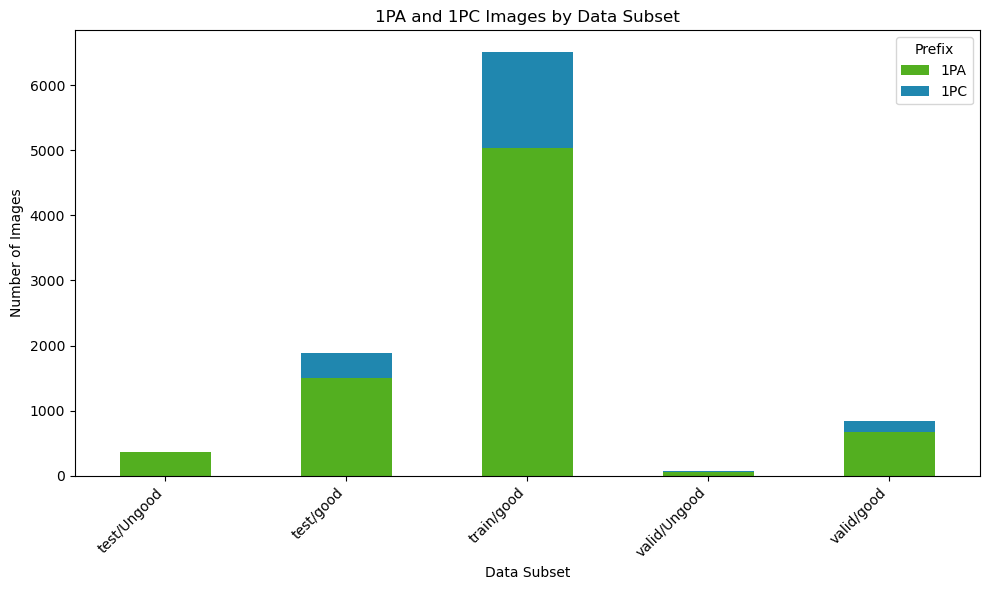

In [5]:
dataset_path = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\dataset\synth23_pelvis_v8_png'
df = analyze_data_stats_by_split(dataset_path)
if df is not None:
    agg = prepare_stacked_bar_data(df)
    plot_stacked_prefix_bars(agg)
